# 02 — Stage 1 to tube-centric Stage 2 HDF5

This notebook verifies Stage 1, organizes every requested dataset by tube, creates preprocessing groups, and audits Stage 2 raw/preprocessed/LOT structures.

In [ ]:
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from flowlot.io import Stage2Organizer, audit_stage1, audit_stage2

In [7]:
import h5py
from pathlib import Path

# Adjust paths if necessary relative to your current working directory
stage1_files = [
    Path("../data/stage1_old/BLAST110_stage1.h5"),
    Path("../data/stage1_old/LAIP29_stage1.h5"),
    Path("../data/stage1_old/FLOWCAPII_stage1.h5"),
]

print(f"Current Working Directory: {Path.cwd()}")

for p in stage1_files:
    print(f"\nChecking: {p.resolve()}")
    if not p.exists():
        print("  -> File does NOT exist at this path.")
        continue

    print("  -> File found. Inspecting contents...")
    try:
        with h5py.File(p, "r") as f:
            # Iterating top-level keys first to quickly test heap integrity
            for key in f.keys():
                pass
        print(f"  -> OK: {p.name}")
    except Exception as e:
        print(f"  -> CORRUPTED: {p.name}")
        print(f"     Error details: {e}")


Current Working Directory: /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/notebooks

Checking: /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage1_old/BLAST110_stage1.h5
  -> File found. Inspecting contents...
  -> OK: BLAST110_stage1.h5

Checking: /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage1_old/LAIP29_stage1.h5
  -> File found. Inspecting contents...
  -> OK: LAIP29_stage1.h5

Checking: /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage1_old/FLOWCAPII_stage1.h5
  -> File found. Inspecting contents...
  -> OK: FLOWCAPII_stage1.h5


## Configuration

Use `strict` marker policy when every patient must have identical ordered markers; use `intersection` to retain the ordered common markers in each tube. Marker subsets may be global lists, per-tube dictionaries, or `None` for all available markers.

In [ ]:
from pathlib import Path
import h5py
import pandas as pd
from flowlot.io import Stage2Organizer, audit_stage1

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
STAGE1_DIR = PROJECT_ROOT / 'data' / 'stage1'
STAGE2 = PROJECT_ROOT / 'data' / 'stage2' / 'stage2_analytics.h5'
STAGE2.parent.mkdir(parents=True, exist_ok=True)

CONFIGURATIONS = [
    {
        'dataset': 'BLAST110', 'cells': 1000, 'marker_policy': 'intersection',
        'stage1': STAGE1_DIR / 'BLAST110_stage1.h5',
        'preprocess': '1', 'markers': None, 'arcsinh_cofactor': None,
    },
    {
        'dataset': 'LAIP29', 'cells': 1000, 'marker_policy': 'intersection',
        'stage1': STAGE1_DIR / 'LAIP29_stage1.h5',
        'preprocess': '1', 'markers': None, 'arcsinh_cofactor': None,
    },
    {
        'dataset': 'FLOWCAPII', 'cells': 1000, 'marker_policy': 'intersection',
        'stage1': STAGE1_DIR / 'FLOWCAPII_stage1.h5',
        'preprocess': '1', 'markers': None, 'arcsinh_cofactor': None,
    },
]

RUN_ORGANIZE = True

METADATA_MARKERS = {'time', 'eventid', 'eventidentifier'}
WIDTH_MARKERS = {'fscw', 'sscw'}
SCATTER_ALIASES = {
    'FSC-A': ('FSC-A', 'FSC A', 'FSC'),
    'FSC-H': ('FSC-H', 'FSC H'),
    'SSC-A': ('SSC-A', 'SSC A', 'SSC'),
    'SSC-H': ('SSC-H', 'SSC H'),
}
BLAST_GATE_ALIASES = {
    'FSC': ('FSC-A', 'FSC-H', 'FSC A', 'FSC H', 'FSC'),
    'SSC': ('SSC-A', 'SSC-H', 'SSC A', 'SSC H', 'SSC'),
    'CD45': ('CD45', 'CD45 KO', 'CD45 ECD'),
    'CD34': ('CD34', 'CD34 Cy55_I', 'CD34 PC5'),
    'CD117': ('CD117', 'CD117_PC7', 'CD117 PE'),
}


def _marker_key(value):
    return ''.join(character for character in str(value).lower() if character.isalnum())


def _is_metadata_marker(value):
    marker = _marker_key(value)
    return marker in METADATA_MARKERS or marker.startswith('time') or marker.startswith('eventid')


def _is_width_marker(value):
    marker = _marker_key(value)
    return marker in WIDTH_MARKERS or marker.startswith('fscw') or marker.startswith('sscw')


def _resolve_marker(available, aliases):
    by_key = {_marker_key(marker): marker for marker in available}
    for alias in aliases:
        if _marker_key(alias) in by_key:
            return by_key[_marker_key(alias)]
    for marker in available:
        marker_key = _marker_key(marker)
        if any(_marker_key(alias) in marker_key for alias in aliases):
            return marker
    return None


def _panel_selection(dataset, available):
    """Select valid features using dataset-specific relaxed validation."""

    valid = [
        marker for marker in available
        if not _is_metadata_marker(marker) and not _is_width_marker(marker)
    ]
    scatter = []
    for canonical, aliases in SCATTER_ALIASES.items():
        marker = _resolve_marker(valid, aliases)
        if marker is not None:
            scatter.append(marker)
    scatter_keys = {_marker_key(marker) for marker in scatter}
    fluorescence = [marker for marker in valid if _marker_key(marker) not in scatter_keys]
    ordered = scatter + fluorescence
    minimum = 7 if dataset == 'FLOWCAPII' else 1
    if len(ordered) < minimum:
        return None, f'preprocess1 has {len(ordered)} valid features; requires at least {minimum}'
    return ordered, f'{len(ordered)} valid features retained'


def _blast_selection(available):
    selected = []
    for feature in ('FSC-A', 'FSC-H', 'SSC-A', 'SSC-H'):
        aliases = SCATTER_ALIASES[feature]
        marker = _resolve_marker(available, aliases)
        if marker is not None and marker not in selected:
            selected.append(marker)
    for feature in ('CD45', 'CD34', 'CD117', 'CD33', 'HLA-DR'):
        aliases = BLAST_GATE_ALIASES.get(feature, (feature,))
        marker = _resolve_marker(available, aliases)
        if marker is not None and marker not in selected:
            selected.append(marker)
        if len(selected) == 7:
            break
    if len(selected) < 7:
        return None, f'blast panel has {len(selected)} available features; requires 7'
    return selected[:7], '7 blast-gating features retained'

## Verify the input Stage 1 file

Do not organize a Stage 1 file with invariant failures. The inventory also exposes patient/tube coverage and marker dimensions before conversion.

In [10]:
for config in CONFIGURATIONS:
    stage1 = config['stage1']
    if not stage1.exists():
        print(f"Skipping {config['dataset']}: no Stage 1 file at {stage1.resolve()}")
        continue
    
    print(f"Auditing {config['dataset']} at {stage1.resolve()}...")
    
    try:
        stage1_inventory, stage1_issues = audit_stage1(stage1)
    except RuntimeError as e:
        print(f"❌ CRITICAL ERROR: {config['dataset']} file is corrupted!")
        print(f"Details: {e}\n")
        continue

    print(f"{config['dataset']}: rows={len(stage1_inventory)}, issues={len(stage1_issues)}")
    # ... rest of your display code ...

    stage1 = config['stage1']
    if not stage1.exists():
        print(f"Skipping {config['dataset']}: no Stage 1 file at {stage1.resolve()}")
        continue
    stage1_inventory, stage1_issues = audit_stage1(stage1)
    print(f"{config['dataset']}: rows={len(stage1_inventory)}, issues={len(stage1_issues)}")
    display(stage1_inventory.groupby(['dataset', 'cell_count', 'tube', 'label']).agg(
        patients=('patient_id', 'nunique'), cells=('n_cells', 'sum'), markers=('n_markers', 'first')
    ).reset_index())
    if not stage1_issues.empty:
        display(stage1_issues)
        raise AssertionError(f'Correct Stage 1 errors for {config["dataset"]} before organizing Stage 2')

Auditing BLAST110 at /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage1_old/BLAST110_stage1.h5...
❌ CRITICAL ERROR: BLAST110 file is corrupted!
Details: Link iteration failed (bad local heap signature)

Auditing LAIP29 at /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage1_old/LAIP29_stage1.h5...
LAIP29: rows=246, issues=0
LAIP29: rows=246, issues=0


,dataset,cell_count,tube,label,patients,cells,markers
0,LAIP29,10,P1,AML_Dx,20,200,16
1,LAIP29,10,P1,AML_FU,15,150,16
2,LAIP29,10,P2,AML_Dx,17,170,16
3,LAIP29,10,P2,AML_FU,14,140,16
4,LAIP29,10,P3,AML_Dx,7,70,14
5,LAIP29,10,P3,AML_FU,5,50,14
6,LAIP29,10,P4,AML_Dx,3,30,14
7,LAIP29,10,P4,AML_FU,1,10,16
8,LAIP29,1000,P1,AML_Dx,20,20000,16
9,LAIP29,1000,P1,AML_FU,15,15000,16


Auditing FLOWCAPII at /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage1_old/FLOWCAPII_stage1.h5...
FLOWCAPII: rows=8616, issues=0
FLOWCAPII: rows=8616, issues=0


,dataset,cell_count,tube,label,patients,cells,markers
0,FLOWCAPII,10,P1,aml,43,430,7
1,FLOWCAPII,10,P1,normal,316,3160,7
2,FLOWCAPII,10,P2,aml,43,430,7
3,FLOWCAPII,10,P2,normal,316,3160,7
4,FLOWCAPII,10,P3,aml,43,430,7
5,FLOWCAPII,10,P3,normal,316,3160,7
6,FLOWCAPII,10,P4,aml,43,430,7
7,FLOWCAPII,10,P4,normal,316,3160,7
8,FLOWCAPII,10,P5,aml,43,430,7
9,FLOWCAPII,10,P5,normal,316,3160,7


## Organize and preprocess

`preprocess_1` removes metadata channels (`Time`, `event_ID`) and unstable pulse-width channels (`FSC-W`, `SSC-W`), including suffix variants. AML tubes retain every remaining valid channel in scatter-first order; FLOWCAPII tubes are accepted when at least 7 valid channels remain. `preprocess_2` selects 7 available blast-gating channels from FSC, SSC, CD45, CD34, CD117, CD33, and HLA-DR using suffix-aware matching. Every tube reports original channels, extracted channels, and a skip reason when applicable.

In [ ]:
import pandas as pd

organize_results = []
panel_results = []

if RUN_ORGANIZE:
    for config in CONFIGURATIONS:
        dataset_name = config['dataset']
        if not config['stage1'].exists():
            detail = f'no Stage 1 input at {config["stage1"]}'
            print(f'SKIPPED {dataset_name}: {detail}')
            organize_results.append({'dataset': dataset_name, 'status': 'skipped', 'detail': detail})
            continue

        try:
            organizer = Stage2Organizer(config['stage1'], STAGE2)
            organizer.organize(
                dataset_name,
                config['cells'],
                marker_policy=config['marker_policy'],
                overwrite=True,
            )

            with h5py.File(STAGE2, 'r') as handle:
                base = handle[f"{dataset_name}/{config['cells']}"]
                preprocess1_markers = {}
                preprocess1_skipped = []
                preprocess2_markers = {}
                preprocess2_skipped = []
                for tube_id, tube in base.items():
                    available = [
                        value.decode() if isinstance(value, bytes) else str(value)
                        for value in tube['metadata/marker_descriptions'][...]
                    ]
                    print(f'{dataset_name}/{tube_id}: original ({len(available)}): {available}')
                    selected, reason = _panel_selection(dataset_name, available)
                    print(
                        f'{dataset_name}/{tube_id}: preprocess_1 '
                        f'({len(selected or [])}): {selected or []}; detail={reason}'
                    )
                    if selected is None:
                        preprocess1_skipped.append(tube_id)
                        panel_results.append({
                            'dataset': dataset_name, 'tube': tube_id,
                            'preprocess': 'preprocess_1', 'status': 'skipped',
                            'markers': '', 'detail': reason,
                        })
                    else:
                        preprocess1_markers[tube_id] = selected
                        panel_results.append({
                            'dataset': dataset_name, 'tube': tube_id,
                            'preprocess': 'preprocess_1', 'status': 'selected',
                            'markers': ';'.join(selected), 'detail': reason,
                        })

                    if dataset_name in {'BLAST110', 'LAIP29'}:
                        selected, reason = _blast_selection(available)
                        print(
                            f'{dataset_name}/{tube_id}: preprocess_2 '
                            f'({len(selected or [])}): {selected or []}; detail={reason}'
                        )
                        if selected is None:
                            preprocess2_skipped.append(tube_id)
                        else:
                            preprocess2_markers[tube_id] = selected
                        panel_results.append({
                            'dataset': dataset_name, 'tube': tube_id,
                            'preprocess': 'preprocess_2',
                            'status': 'selected' if selected is not None else 'skipped',
                            'markers': ';'.join(selected or []), 'detail': reason,
                        })

            organizer.add_preprocess(
                dataset_name,
                config['cells'],
                '1',
                marker_subset=preprocess1_markers,
                arcsinh_cofactor=config['arcsinh_cofactor'],
                skip_tubes=preprocess1_skipped,
            )
            if dataset_name in {'BLAST110', 'LAIP29'}:
                organizer.add_preprocess(
                    dataset_name,
                    config['cells'],
                    '2',
                    marker_subset=preprocess2_markers,
                    arcsinh_cofactor=config['arcsinh_cofactor'],
                    skip_tubes=preprocess2_skipped,
                )
            organize_results.append({'dataset': dataset_name, 'status': 'ok', 'detail': ''})
            print(
                f"OK {dataset_name}/{config['cells']} + preprocess "
                f"'{config['preprocess']}' -> {STAGE2.resolve()}"
            )
        except Exception as error:
            organize_results.append({
                'dataset': dataset_name,
                'status': 'failed',
                'detail': repr(error),
            })
            print(f'FAILED {dataset_name}: {error!r}')

    display(pd.DataFrame(organize_results))
    display(pd.DataFrame(panel_results))
else:
    print('Dry run. Set RUN_ORGANIZE=True after Stage 1 passes verification.')

TEMPORARILY SKIPPED BLAST110: pending fix
OK LAIP29/1000 + preprocess 'common12' -> /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage2/stage2_analytics.h5
OK FLOWCAPII/1000 + preprocess 'common12' -> /home/qpb3vt/Drive/Naqib/2026_AML_projects_folder/Projects/P1_FlowLOT_opencode/data/stage2/stage2_analytics.h5


,dataset,status
0,LAIP29,ok
1,FLOWCAPII,ok


## Verify Stage 2 and summarize every dataset

Checks cover metadata lengths, patient alignment, marker dimensions, preprocessing coverage, finite values, embedding rows, and flattened LOT widths.

In [13]:
if STAGE2.exists():
    inventories, stage2_issues = audit_stage2(STAGE2)
    raw, processed, embeddings = inventories['raw'], inventories['preprocess'], inventories['embeddings']
    raw_summary = raw.groupby(['dataset', 'cell_count', 'tube', 'label']).agg(
        patients=('patient_id', 'nunique'), stored_cells=('n_cells', 'sum'),
        median_cells=('n_cells', 'median'), markers=('n_markers', 'first'),
        finite_fraction=('finite_fraction', 'min'),
    ).reset_index()
    display(raw_summary)
    display(processed.groupby(['dataset', 'cell_count', 'tube', 'preprocess']).agg(
        patients=('patient_id', 'nunique'), markers=('n_markers', 'first'),
        finite_fraction=('finite_fraction', 'min'),
    ).reset_index())
    display(embeddings)
    display(stage2_issues)
    assert stage2_issues.empty, 'Stage 2 verification failed; inspect stage2_issues'
else:
    print('Stage 2 does not exist yet.')

,dataset,cell_count,tube,label,patients,stored_cells,median_cells,markers,finite_fraction
0,FLOWCAPII,1000,P1,aml,43,43000,1000.0,7,1.0
1,FLOWCAPII,1000,P1,normal,316,316000,1000.0,7,1.0
2,FLOWCAPII,1000,P2,aml,43,43000,1000.0,5,1.0
3,FLOWCAPII,1000,P2,normal,316,316000,1000.0,5,1.0
4,FLOWCAPII,1000,P3,aml,43,43000,1000.0,7,1.0
5,FLOWCAPII,1000,P3,normal,316,316000,1000.0,7,1.0
6,FLOWCAPII,1000,P4,aml,43,43000,1000.0,7,1.0
7,FLOWCAPII,1000,P4,normal,316,316000,1000.0,7,1.0
8,FLOWCAPII,1000,P5,aml,43,43000,1000.0,7,1.0
9,FLOWCAPII,1000,P5,normal,316,316000,1000.0,7,1.0


,dataset,cell_count,tube,preprocess,patients,markers,finite_fraction
0,FLOWCAPII,1000,P1,common12,359,7,1.0
1,FLOWCAPII,1000,P2,common12,359,5,1.0
2,FLOWCAPII,1000,P3,common12,359,7,1.0
3,FLOWCAPII,1000,P4,common12,359,7,1.0
4,FLOWCAPII,1000,P5,common12,359,7,1.0
5,FLOWCAPII,1000,P6,common12,359,6,1.0
6,FLOWCAPII,1000,P7,common12,359,7,1.0
7,FLOWCAPII,1000,P8,common12,359,7,1.0
8,LAIP29,1000,P1,common12,35,12,1.0
9,LAIP29,1000,P2,common12,31,9,1.0


""


,severity,location,check,message


tube                                    P1  P2  P3  P4  P5  P6  P7  P8
dataset   cell_count patient_id label                                 
FLOWCAPII 1000       1          normal   1   1   1   1   1   1   1   1
                     10         normal   1   1   1   1   1   1   1   1
                     100        normal   1   1   1   1   1   1   1   1
                     101        aml      1   1   1   1   1   1   1   1
                     102        normal   1   1   1   1   1   1   1   1
                     103        aml      1   1   1   1   1   1   1   1
                     104        normal   1   1   1   1   1   1   1   1
                     105        aml      1   1   1   1   1   1   1   1
                     106        normal   1   1   1   1   1   1   1   1
                     107        normal   1   1   1   1   1   1   1   1
                     108        normal   1   1   1   1   1   1   1   1
                     109        normal   1   1   1   1   1   1   1   1
                     11         normal   1   1   1   1   1   1   1   1
                     110        normal   1   1   1   1   1   1   1   1
                     111        normal   1   1   1   1   1   1   1   1
                     112        normal   1   1   1   1   1   1   1   1
                     113        normal   1   1   1   1   1   1   1   1
                     114        normal   1   1   1   1   1   1   1   1
                     115        normal   1   1   1   1   1   1   1   1
                     116        aml      1   1   1   1   1   1   1   1

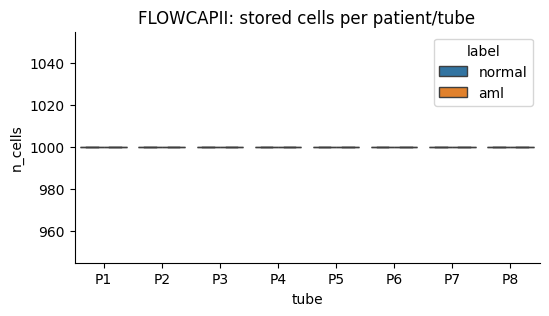

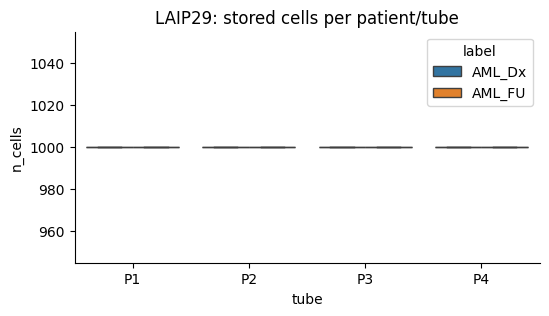

In [14]:
if STAGE2.exists():
    coverage = raw.assign(present=1).pivot_table(
        index=['dataset', 'cell_count', 'patient_id', 'label'], columns='tube',
        values='present', aggfunc='max', fill_value=0,
    )
    display(coverage.head(20))
    for dataset, values in raw.groupby('dataset'):
        figure, axis = plt.subplots(figsize=(6, 3))
        sns.boxplot(data=values, x='tube', y='n_cells', hue='label', ax=axis)
        axis.set_title(f'{dataset}: stored cells per patient/tube')
        sns.despine()
        plt.show()

In [15]:
if STAGE2.exists():
    with h5py.File(STAGE2) as handle:
        print('schema:', dict(handle.attrs))
        for dataset in handle:
            for cells in handle[dataset]:
                print(f'/{dataset}/{cells} tubes:', sorted(handle[f'{dataset}/{cells}']))

schema: {'schema': 'flowlot-stage2', 'schema_version': '1.0'}
/FLOWCAPII/1000 tubes: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']
/LAIP29/1000 tubes: ['P1', 'P2', 'P3', 'P4']
